In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns


In [6]:
ukr_database = pd.read_csv(
    "data/uadatabase.csv",
    low_memory=False
)

event2022 = pd.read_csv(
    "data/event_1pd_latest_2022.csv",
    low_memory=False
)
event2023 = pd.read_csv(
    "data/event_1pd_latest_2023.csv",
    low_memory=False
)
event2024 = pd.read_csv(
    "data/event_1pd_latest_2024.csv",
    low_memory=False
)
event2025 = pd.read_csv(
    "data/event_1pd_latest_2025.csv",
    low_memory=False
)
event2026 = pd.read_csv(
    "data/event_1pd_latest_2026.csv",
    low_memory=False
)

poteru = pd.read_csv(
    "data/poteru_rus.csv",
    low_memory=False
)

rus_officers = pd.read_csv(
    "data/rus_ofc_kia.csv",
    low_memory=False
)

events = pd.concat(
    [event2022, event2023, event2024, event2025, event2026],
    ignore_index=True
)
# Convert dates only if they have not already been converted
if not pd.api.types.is_datetime64_any_dtype(events["date"]):
    events["date"] = pd.to_datetime(
        events["date"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True),
        format="%Y%m%d",
        errors="coerce"
    )

events = events[
    events["date"].notna()
    & (events["date"] >= WAR_START)
].copy()

events["month"] = (
    events["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

binary_columns = [
    "t_mil_b",
    "t_uav_b",
    "t_artillery_b",
    "t_armor_b",
    "t_airstrike_b",
    "t_milcas_b",
    "t_civcas_b"
]

for column in binary_columns:
    events[column] = (
        pd.to_numeric(events[column], errors="coerce")
        .fillna(0)
        .gt(0.5)
    )

military_events = events[
    events["t_mil_b"]
].copy()

tactics = {
    "Drone": "t_uav_b",
    "Artillery": "t_artillery_b",
    "Armored warfare": "t_armor_b",
    "Airstrike": "t_airstrike_b"
}

print("Total events:", len(events))
print("Military events:", len(military_events))
print("Date range:", events["date"].min(), "to", events["date"].max())

print(events.shape)
events.head()


Total events: 407857
Military events: 307793
Date range: 2022-02-24 00:00:00 to 2026-07-28 00:00:00
(407857, 45)


,viina_version,event_id_1pd,date,n_reports,event_ids,sources,geonameid,feature_code,asciiname,ADM1_NAME,...,t_property_b,t_cyber_b,t_hospital_b,t_milcas_b,t_civcas_b,t_retreat_b,t_loc_b,t_san_b,tid,month
0,bert_20250404023629,181411,2022-02-24,1,2280071,24tvua,705183.0,PPL,Slobozhans'ke,Kharkiv,...,0,0,0,False,False,0,NaN,NaN,NaN,2022-02-01
1,bert_20250404023629,145113,2022-02-24,2,"2279021, 2276365",24tvua,703448.0,PPLC,Kyiv,Kiev City,...,0,0,0,False,False,0,NaN,NaN,NaN,2022-02-01
2,bert_20250404023629,233218,2022-02-24,1,2276366,24tvua,709354.0,PPLA2,Toretsk,Donets'k,...,0,0,0,False,False,0,NaN,NaN,NaN,2022-02-01
3,bert_20250404023629,173537,2022-02-24,1,2276367,24tvua,704422.0,PPLA2,Pokrovsk,Donets'k,...,0,0,0,False,False,0,NaN,NaN,NaN,2022-02-01
4,bert_20250404023629,88465,2022-02-24,1,2276368,24tvua,698020.0,PPL,Pankivka,Luhans'k,...,0,0,0,False,False,0,NaN,NaN,NaN,2022-02-01


In [7]:
os.makedirs("figures", exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")

WAR_START = pd.Timestamp("2022-02-24")

COLORS = {
    "Drone": "#d73027",
    "Artillery": "#4575b4",
    "Armored warfare": "#4d4d4d",
    "Airstrike": "#fdae61"
}

events["date"] = pd.to_datetime(
    events["date"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

events = events[
    events["date"] >= WAR_START
].copy()

events["month"] = (
    events["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

binary_columns = [
    "t_mil_b",
    "t_uav_b",
    "t_artillery_b",
    "t_armor_b",
    "t_airstrike_b",
    "t_milcas_b",
    "t_civcas_b"
]

for column in binary_columns:
    events[column] = (
        pd.to_numeric(events[column], errors="coerce")
        .fillna(0)
        .gt(0.5)
    )

military_events = events[
    events["t_mil_b"]
].copy()

tactics = {
    "Drone": "t_uav_b",
    "Artillery": "t_artillery_b",
    "Armored warfare": "t_armor_b",
    "Airstrike": "t_airstrike_b"
}

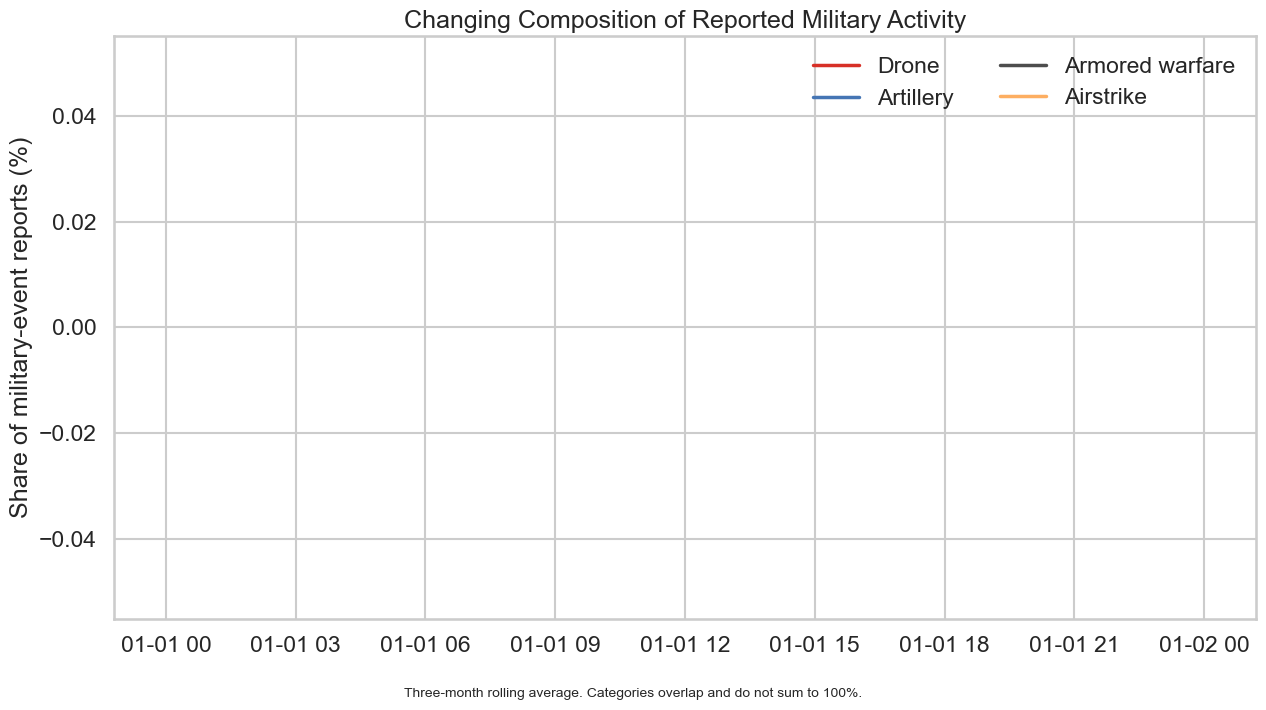

In [8]:
# Count all military reports each month
monthly_total = (
    military_events
    .groupby("month")
    .size()
)

# Create empty dataframe for percentages
tactic_share = pd.DataFrame(
    index=monthly_total.index
)

# Calculate each tactic's monthly share
for label, column in tactics.items():
    monthly_count = (
        military_events
        .groupby("month")[column]
        .sum()
    )

    tactic_share[label] = (
        monthly_count
        .div(monthly_total)
        .mul(100)
    )

# Smooth the lines using a three-month rolling average
tactic_share_smoothed = tactic_share.rolling(
    window=3,
    center=True,
    min_periods=1
).mean()

# Plot
plt.figure(figsize=(13, 7))

for tactic in tactic_share_smoothed.columns:
    plt.plot(
        tactic_share_smoothed.index,
        tactic_share_smoothed[tactic],
        label=tactic,
        color=COLORS[tactic],
        linewidth=2.5
    )

plt.title("Changing Composition of Reported Military Activity")
plt.ylabel("Share of military-event reports (%)")
plt.xlabel("")
plt.legend(frameon=False, ncol=2)

plt.figtext(
    0.5,
    -0.02,
    "Three-month rolling average. Categories overlap and do not sum to 100%.",
    ha="center",
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "figures/01_viina_tactic_shares.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()